# World Model Reconstruction Analysis

## Posterior Rollout: Can the model reconstruct what it has actually seen?

This notebook evaluates the **posterior reconstruction** capability of the DreamerV3 world model on Spot robot trajectories.

### Procedure:
1. Load a real trajectory: observations $o_{1:T}$, actions $a_{1:T}$
2. Encode observations → embeddings via encoder
3. Run RSSM with posterior updates: $z_t \sim q(z_t \mid z_{t-1}, a_{t-1}, o_t)$
4. Decode each latent: $\hat{o}_t = \text{decoder}(z_t)$
5. Compare: original $o_t$ vs reconstructed $\hat{o}_t$

In [1]:

import sys
import pickle
from pathlib import Path

# Setup paths
notebook_dir = Path('/home/maurits-heemskerk/Documents/Uni/Master_Thesis/dreamer_SPOT_implementation/notebooks')
dreamer_dir  = Path('/home/maurits-heemskerk/Documents/Uni/Master_Thesis/dreamer_SPOT_implementation/informed-dreamer')
sys.path.insert(0, str(dreamer_dir))

# Core imports
import numpy as np
import jax
import jax.numpy as jnp
import h5py
import matplotlib.pyplot as plt
import ruamel.yaml as yaml
import re

# DreamerV3 imports
import dreamerv3
import dreamerv3.embodied as embodied

jax.config.update('jax_transfer_guard', 'allow')

print(f"✓ JAX version: {jax.__version__}")
print(f"✓ Devices: {jax.devices()}")
print(f"✓ Imports successful")


✓ JAX version: 0.4.28
✓ Devices: [cuda(id=0)]
✓ Imports successful


## Configuration

In [2]:

import re

results_dir = Path('/home/maurits-heemskerk/Documents/Uni/Master_Thesis/dreamer_results_local_noobs')
DATA_DIR = Path('/home/maurits-heemskerk/Documents/Uni/Master_Thesis/dreamer_SPOT_implementation/informed-dreamer/processed_data')

available_runs = sorted([d for d in results_dir.iterdir() if d.is_dir()])
print("Available runs:")
for i, d in enumerate(available_runs):
    ok = (d / 'checkpoint.ckpt').exists() and (d / 'config.yaml').exists()
    print(f"  [{i:2d}] {'✓' if ok else '⚠'} {d.name}")

# ── Select run ──────────────────────────────────────────────────────────────
RUN_INDEX = 18 # ← change to select a different run

run_path = available_runs[RUN_INDEX]
CHECKPOINT_PATH = run_path / 'checkpoint.ckpt'
config_file = run_path / 'config.yaml'

assert CHECKPOINT_PATH.exists(), f"Checkpoint not found: {CHECKPOINT_PATH}"
assert config_file.exists(), f"Config not found: {config_file}"
assert DATA_DIR.exists(), f"Data directory not found: {DATA_DIR}"

with open(config_file) as f:
    raw_config = yaml.YAML(typ='safe').load(f)

# ── Scan which observations the encoder uses ─────────────────────────────────
_enc_mlp = raw_config['encoder']['mlp_keys']
_enc_cnn = raw_config['encoder']['cnn_keys']
_ALL_MLP = ['velocity', 'orientation', 'goal', 'position']
_ALL_CNN = ['image', 'terrain', 'info_terrain']
mlp_keys = [k for k in _ALL_MLP if _enc_mlp and re.search(_enc_mlp, k)]
cnn_keys = [k for k in _ALL_CNN if _enc_cnn and re.search(_enc_cnn, k)]
obs_keys  = mlp_keys + cnn_keys

print(f"\n✓ Run:        {run_path.name}")
print(f"✓ Checkpoint: {CHECKPOINT_PATH.name}")
print(f"\nEncoder observation scan:")
print(f"  mlp_keys pattern: {_enc_mlp!r}  →  {mlp_keys}")
print(f"  cnn_keys pattern: {_enc_cnn!r}  →  {cnn_keys}")
print(f"\n→ Active observation keys: {obs_keys}")
print(f"\nRSSM deter={raw_config['rssm']['deter']}  stoch={raw_config['rssm']['stoch']}")


Available runs:
  [ 0] ✓ rewardsv2_large_baseline
  [ 1] ✓ rewardsv2_large_dyn_rep
  [ 2] ✓ rewardsv2_large_multistep
  [ 3] ✓ rewardsv2_large_realtd
  [ 4] ✓ rewardsv2_large_warmup
  [ 5] ✓ rewardsv2_medium_baseline
  [ 6] ✓ rewardsv2_medium_dyn_rep
  [ 7] ✓ rewardsv2_medium_multistep
  [ 8] ✓ rewardsv2_medium_realtd
  [ 9] ✓ rewardsv2_medium_warmup
  [10] ✓ rewardsv3_kl_baseline
  [11] ✓ rewardsv3_kl_high_both
  [12] ✓ rewardsv3_kl_high_dyn
  [13] ✓ rewardsv3_kl_high_rep
  [14] ✓ rewardsv3_kl_low_dyn
  [15] ⚠ rewardsv3_large_agent
  [16] ⚠ rewardsv3_medium_agent
  [17] ✓ rewardsv3_medium_dyn_rep
  [18] ✓ rewardsv3_medium_imag25
  [19] ✓ rewardsv3_medium_vector2
  [20] ✓ rewardsv3_perf_batch12
  [21] ✓ rewardsv3_perf_combo_bestguess
  [22] ✓ rewardsv3_perf_imag10
  [23] ✓ rewardsv3_perf_rep0.2
  [24] ✓ rewardsv3_perf_stoch48
  [25] ✓ rewardsv3_perf_trainratio256
  [26] ✓ rewardsv3_small_rssm
  [27] ⚠ rewardsv3_xlarge_agent

✓ Run:        rewardsv3_medium_imag25
✓ Checkpoint: checkpoin

## Load Checkpoint

In [3]:

from dreamerv3.agent import WorldModel

# ── Build embodied config ─────────────────────────────────────────────────────
_defaults = embodied.Config(dreamerv3.Agent.configs['defaults'])
_known_keys = set(_defaults.keys()) - {'env'}

def _filter_to_known(cfg, ref):
    """Recursively drop keys not present in ref (handles old checkpoints with missing/extra keys)."""
    out = {}
    for k, v in cfg.items():
        if k not in ref:
            continue
        if isinstance(v, dict) and isinstance(ref[k], dict):
            out[k] = _filter_to_known(v, ref[k])
        else:
            out[k] = v
    return out

_model_config = _filter_to_known(
    {k: v for k, v in raw_config.items() if k in _known_keys},
    dict(_defaults)
)

config = embodied.Config(dreamerv3.Agent.configs['defaults'])
config = config.update(_model_config)
config = config.update({'jax.platform': 'cpu', 'jax.prealloc': False})

# ── Fixed obs/act space — matched exactly to our new checkpoints ──────────────
# Obs: velocity (3,)=[vx,vy,wz]  orientation (2,)=[cos,sin]  goal (2,)=[dx,dy]
# Act: action   (3,)=[vx,vy,yaw_rate]  — no gait switching
_SPACE_MAP = {
    'velocity':    embodied.Space(np.float32, (3,)),   # [vx, vy, wz]
    'orientation': embodied.Space(np.float32, (2,)),   # [cos(yaw), sin(yaw)]
    'goal':        embodied.Space(np.float32, (2,)),   # [dx, dy] world-relative
    'position':    embodied.Space(np.float32, (2,)),   # kept for reference only
    'image':       embodied.Space(np.uint8,   (49, 128, 3)),
    'terrain':     embodied.Space(np.float32, (64, 64)),
    'info_terrain':embodied.Space(np.float32, (64, 64)),
}
obs_space = {k: _SPACE_MAP[k] for k in obs_keys if k in _SPACE_MAP}
obs_space['reward']      = embodied.Space(np.float32)
obs_space['is_first']    = embodied.Space(bool)
obs_space['is_last']     = embodied.Space(bool)
obs_space['is_terminal'] = embodied.Space(bool)

act_space = {'action': embodied.Space(np.float32, (3,), -1.0, 1.0), 'reset': embodied.Space(bool)}

print(f"✓ obs_space: {[(k, v.shape) for k, v in obs_space.items() if k not in ('reward','is_first','is_last','is_terminal')]}")
print(f"✓ act_space: action {act_space['action'].shape}  (vx, vy, yaw_rate)")

# ── Load and remap checkpoint weights ────────────────────────────────────────
with open(CHECKPOINT_PATH, 'rb') as f:
    checkpoint_data = pickle.load(f)

raw_agent_state = checkpoint_data['agent']
agent_state = {}
for k, v in raw_agent_state.items():
    if k.startswith('agent/wm/'):
        agent_state[k.replace('agent/wm/', 'wm/', 1)] = v

print(f"✓ {len(agent_state)} WM weight tensors mapped  (from {len(raw_agent_state)} total)")

# ── Create WorldModel ─────────────────────────────────────────────────────────
wm = WorldModel(obs_space, act_space, config, name='wm')

print(f"✓ WorldModel ready  (deter={config.rssm['deter']}  stoch={config.rssm['stoch']})")


✓ obs_space: [('velocity', (3,)), ('orientation', (2,)), ('goal', (2,))]
✓ act_space: action (3,)  (vx, vy, yaw_rate)
✓ 79 WM weight tensors mapped  (from 125 total)
Encoder CNN shapes: {}
Encoder MLP shapes: {'velocity': (3,), 'orientation': (2,), 'goal': (2,)}
Decoder CNN shapes: {}
Decoder MLP shapes: {'velocity': (3,), 'orientation': (2,), 'goal': (2,)}
✓ WorldModel ready  (deter=1024  stoch=32)


## Load Episode Data

In [4]:

h5_files = sorted(DATA_DIR.glob('**/*.h5'))
print(f"Found {len(h5_files)} episode files")

episode_file = h5_files[0]
print(f"Loading: {episode_file.name}")

with h5py.File(episode_file, 'r') as f:
    velocities_raw = f['observations/velocities'][:].astype(np.float32)   # (T, 6)
    states         = f['observations/state'][:].astype(np.float32)         # (T, 7)
    actions        = f['actions'][:].astype(np.float32)
    rewards        = f['rewards'][:].astype(np.float32)

num_steps = len(velocities_raw)

# ── Exact feature extraction — matched to new checkpoints ─────────────────────
# velocity (3,): [vx, vy, wz]  — drop vz (idx 2), wx/wy pitch+roll rates (idx 3,4)
velocities = velocities_raw[:, [0, 1, 5]].astype(np.float32)

# Yaw from quaternion
qx, qy, qz, qw = states[:, 3], states[:, 4], states[:, 5], states[:, 6]
yaw = np.arctan2(2.0 * (qw * qz + qx * qy), 1.0 - 2.0 * (qy * qy + qz * qz))
yaw0 = yaw[0]

# orientation (2,): [cos(yaw), sin(yaw)] — absolute, not episode-relative
orientations = np.stack([np.cos(yaw), np.sin(yaw)], axis=-1).astype(np.float32)

# goal (2,): world-relative [goal_x - pos_x, goal_y - pos_y]
xy_raw = states[:, :2]
goal_position = xy_raw[-1]
goal_relative = (goal_position[None, :] - xy_raw).astype(np.float32)

# position kept for reference / goal computation only — not fed to encoder
positions = (xy_raw - xy_raw[0]).astype(np.float32)

# ── Build obs_batch with exactly the keys the encoder uses ───────────────────
# obs_keys = ['velocity', 'orientation', 'goal']  (from config scan above)
_data_map = {
    'velocity':    velocities,
    'orientation': orientations,
    'goal':        goal_relative,
    'position':    positions,   # kept in map; only included if obs_keys contains it
}
obs_batch = {k: np.expand_dims(_data_map[k], 0) for k in obs_keys if k in _data_map}
obs_batch['is_first']    = np.zeros((1, num_steps), dtype=bool)
obs_batch['is_last']     = np.zeros((1, num_steps), dtype=bool)
obs_batch['is_terminal'] = np.zeros((1, num_steps), dtype=bool)
obs_batch['reward']      = np.zeros((1, num_steps), dtype=np.float32)
obs_batch['is_first'][0, 0]  = True
obs_batch['is_last'][0, -1]  = True

actions_batch = np.expand_dims(actions[:, :3], 0)   # slice to 3-dim action space
actions_prev_batch = np.concatenate([np.zeros_like(actions_batch[:, :1]), actions_batch[:, :-1]], axis=1)

print(f"✓ Episode length: {num_steps}")
print(f"✓ yaw0 (deg): {np.degrees(yaw0):.2f}")
print(f"✓ obs_batch keys/shapes:")
for k, v in obs_batch.items():
    if not k.startswith('is_') and k != 'reward':
        print(f"    {k}: {v.shape}")
print(f"✓ actions_batch shape:      {actions_batch.shape}  (vx, vy, yaw_rate)")
print(f"✓ actions_prev_batch shape: {actions_prev_batch.shape}")


Found 2 episode files
Loading: spot_bag_20260217_133435_expert_med_converted.h5
✓ Episode length: 65
✓ yaw0 (deg): -0.00
✓ obs_batch keys/shapes:
    velocity: (1, 65, 3)
    orientation: (1, 65, 2)
    goal: (1, 65, 2)
✓ actions_batch shape:      (1, 65, 3)  (vx, vy, yaw_rate)
✓ actions_prev_batch shape: (1, 65, 3)


## Posterior Rollout: Reconstruction

In [5]:

from dreamerv3 import ninjax as nj

print(f"Running posterior inference on {num_steps} timesteps...")

def inference_pipeline():
    embed = wm.encoder(obs_batch)
    post, prior = wm.rssm.observe(embed, actions_prev_batch, obs_batch['is_first'])
    recons = wm.heads['decoder'](post)
    return embed, post, prior, recons

rng_key = jax.random.PRNGKey(42)
(embed, post, prior, recons_dists), _ = nj.pure(inference_pipeline)(agent_state, rng_key)

# Extract reconstructed modalities (squeeze batch dim)
reconstructions = {
    k: np.array(dist.mean()).squeeze(0)
    for k, dist in recons_dists.items()
    if k in obs_keys
}

# Squeeze obs_batch for comparison
obs_flat = {
    k: np.array(v).squeeze(0)
    for k, v in obs_batch.items()
    if k in obs_keys
}

# Raw MSE (physical units)
errors = {
    k: float(np.mean((reconstructions[k] - obs_flat[k]) ** 2))
    for k in reconstructions if k in obs_flat
}

# Scale-normalized MSE to highlight true mismatch independent of unit scale
nmse = {}
for k in errors:
    var = float(np.var(obs_flat[k]))
    nmse[k] = float(errors[k] / (var + 1e-8))

print("✓ Inference complete")
print(f"  Reconstructed keys: {list(reconstructions.keys())}")
print("  Raw MSE (original units):")
for k, mse in errors.items():
    print(f"    {k:12s}: {mse:.6f}")
print("  NMSE (MSE / target variance):")
for k, val in nmse.items():
    print(f"    {k:12s}: {val:.6f}")


Running posterior inference on 65 timesteps...


2026-04-27 13:54:03.916757: W external/xla/xla/service/gpu/nvptx_compiler.cc:760] The NVIDIA driver's CUDA version is 12.2 which is older than the ptxas CUDA version (12.9.86). Because the driver is older than the ptxas version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


✓ Inference complete
  Reconstructed keys: ['velocity', 'orientation', 'goal']
  Raw MSE (original units):
    velocity    : 0.124605
    orientation : 0.011595
    goal        : 0.437877
  NMSE (MSE / target variance):
    velocity    : 2.129222
    orientation : 0.038816
    goal        : 0.379034


In [6]:

# No image encoder in this model — skipping image reconstruction visualization.
print(f"Active obs keys: {obs_keys}")
print("Image encoder not used — skipping image reconstruction visualization.")
print(f"Reconstruction MSE per modality:")
for k, mse in errors.items():
    print(f"  {k}: {mse:.6f}")


Active obs keys: ['velocity', 'orientation', 'goal']
Image encoder not used — skipping image reconstruction visualization.
Reconstruction MSE per modality:
  velocity: 0.124605
  orientation: 0.011595
  goal: 0.437877


In [7]:

# No image encoder — skipping image loss calculation.
print("Image loss not applicable for this model.")


Image loss not applicable for this model.


## Image Quality Deep Dive: Is it Noise or Structure?

Check if reconstructions have spatial structure or are just pixel-level statistical matches.

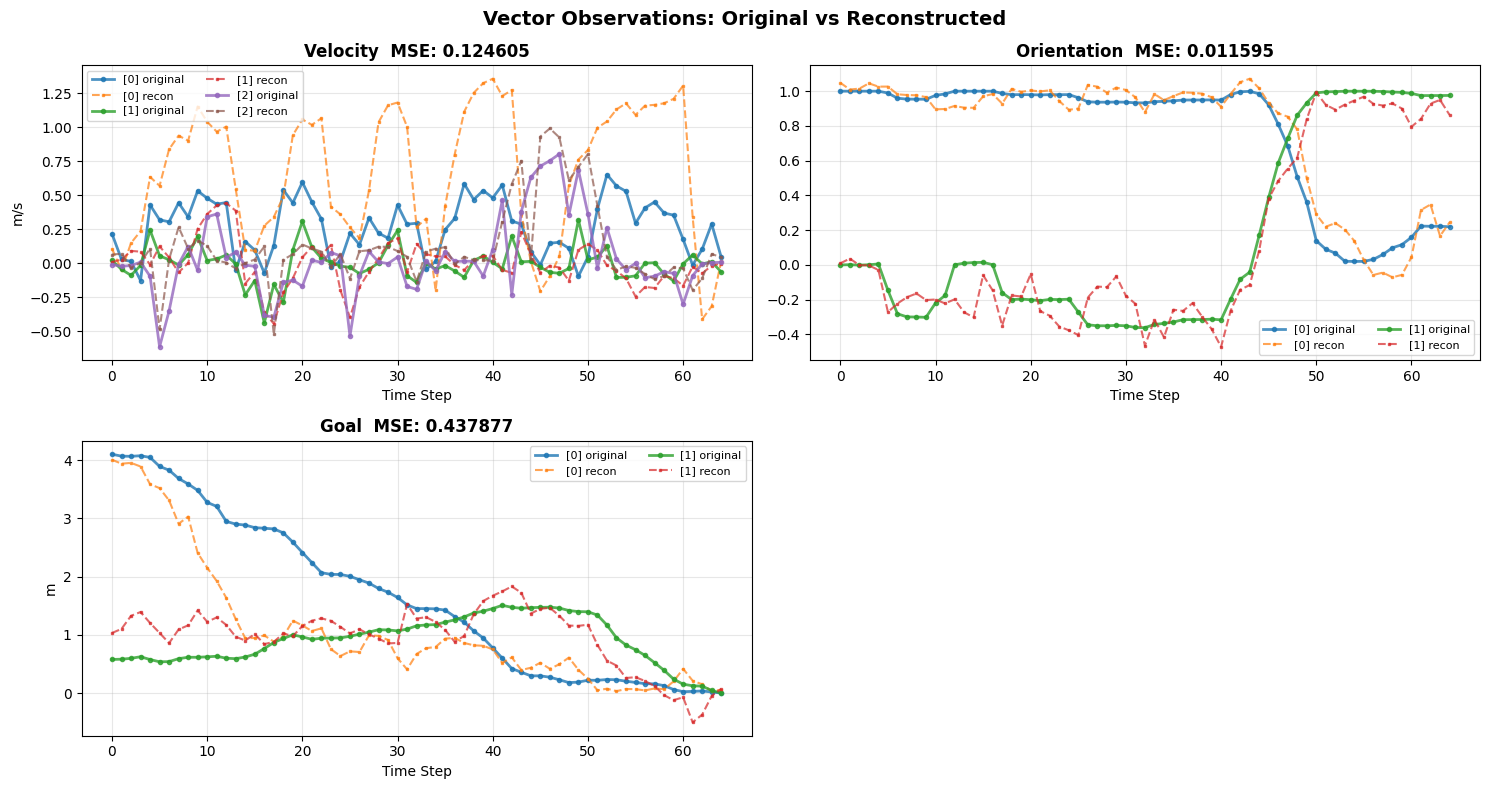

✓ Plotted: ['velocity', 'orientation', 'goal']


In [8]:

available_keys = [k for k in ['velocity', 'orientation', 'goal', 'position']
                  if k in reconstructions and k in obs_flat]

if not available_keys:
    print("No vector observations to visualize.")
else:
    num_plots = len(available_keys)
    ncols = 2
    nrows = (num_plots + ncols - 1) // ncols
    time_steps = np.arange(obs_flat[available_keys[0]].shape[0])

    fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows))
    axes = np.array(axes).flatten()
    fig.suptitle('Vector Observations: Original vs Reconstructed', fontsize=14, fontweight='bold')

    ylabel_map = {'velocity': 'm/s', 'position': 'm', 'orientation': '', 'goal': 'm'}

    for plot_idx, key in enumerate(available_keys):
        ax = axes[plot_idx]
        mse_str = f"MSE: {errors[key]:.6f}" if key in errors else ''
        for dim in range(obs_flat[key].shape[1]):
            ax.plot(time_steps, obs_flat[key][:, dim], 'o-',
                    label=f'[{dim}] original', alpha=0.8, linewidth=2, markersize=3)
            ax.plot(time_steps, reconstructions[key][:, dim], 's--',
                    label=f'[{dim}] recon', alpha=0.7, linewidth=1.5, markersize=2)
        ax.set_title(f"{key.capitalize()}  {mse_str}", fontweight='bold')
        ax.set_xlabel('Time Step')
        ax.set_ylabel(ylabel_map.get(key, ''))
        ax.legend(fontsize=8, loc='best', ncol=2)
        ax.grid(True, alpha=0.3)

    for idx in range(num_plots, len(axes)):
        axes[idx].set_visible(False)

    plt.tight_layout()
    plt.show()
    print(f"✓ Plotted: {available_keys}")


## Terrain Map Reconstruction

Check how well the model reconstructs the 2D terrain elevation map (if it is predicting it).

In [9]:

terrain_key = next((k for k in ['info_terrain', 'terrain'] if k in reconstructions), None)
if terrain_key:
    print(f"Terrain key '{terrain_key}' found in reconstructions — visualization would go here.")
else:
    print("No terrain keys in this model — skipping terrain reconstruction visualization.")
    print(f"Active obs keys: {obs_keys}")


No terrain keys in this model — skipping terrain reconstruction visualization.
Active obs keys: ['velocity', 'orientation', 'goal']


## Optional: Analyze Latent Space Trajectories

Deterministic state (deter) shape: (65, 1024)
Stochastic state (stoch) shape: (65, 32, 32)

Deterministic state statistics:
  Mean norm: 12.4331
  Std norm: 1.6419
  Mean velocity: 7.3229


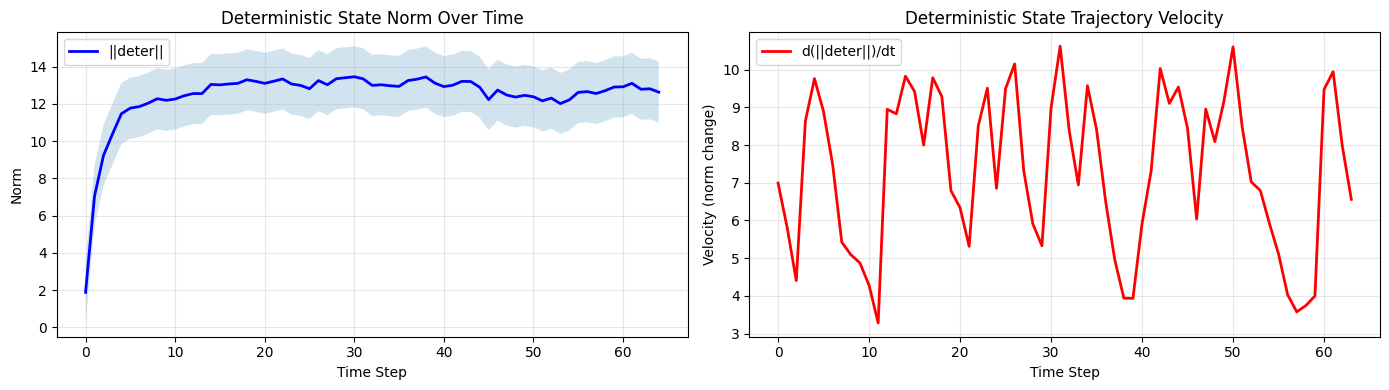


✓ Latent space analysis complete


In [10]:
# ============================================================================
# Analyze the learned latent representations
# ============================================================================

# Extract latent dimensions
deter = np.array(post['deter']).squeeze()  # (T, 512)
stoch = np.array(post['stoch']).squeeze()  # (T, 32, 32) if classes=32

print(f"Deterministic state (deter) shape: {deter.shape}")
print(f"Stochastic state (stoch) shape: {stoch.shape}")

# Compute trajectory statistics
deter_norm = np.linalg.norm(deter, axis=1)
deter_velocity = np.linalg.norm(np.diff(deter, axis=0), axis=1)

print(f"\nDeterministic state statistics:")
print(f"  Mean norm: {deter_norm.mean():.4f}")
print(f"  Std norm: {deter_norm.std():.4f}")
print(f"  Mean velocity: {deter_velocity.mean():.4f}")

# Plot latent trajectories
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Deterministic state norm over time
ax = axes[0]
ax.plot(deter_norm, 'b-', linewidth=2, label='||deter||')
ax.fill_between(np.arange(len(deter_norm)), 
                 deter_norm - np.std(deter_norm), 
                 deter_norm + np.std(deter_norm), 
                 alpha=0.2)
ax.set_xlabel('Time Step')
ax.set_ylabel('Norm')
ax.set_title('Deterministic State Norm Over Time')
ax.grid(True, alpha=0.3)
ax.legend()

# Deterministic state velocity
ax = axes[1]
time_steps_vel = np.arange(len(deter_velocity))
ax.plot(time_steps_vel, deter_velocity, 'r-', linewidth=2, label='d(||deter||)/dt')
ax.set_xlabel('Time Step')
ax.set_ylabel('Velocity (norm change)')
ax.set_title('Deterministic State Trajectory Velocity')
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

print(f"\n✓ Latent space analysis complete")

## Prior Rollout: Open-Loop Dreaming

This section tests the model's ability to 'dream' future states by only encoding the **first frame** and predicting sequentially forward using only the sequence of **actions**.

In [11]:

print("Running Prior Rollout (Open-loop dreaming)...")

def inference_prior():
    first_obs = {k: v[:, 0:1] for k, v in obs_batch.items()}
    first_action = jnp.zeros_like(actions_batch[:, 0:1])
    embed_first = wm.encoder(first_obs)
    post_first, _ = wm.rssm.observe(embed_first, first_action, first_obs['is_first'])
    start_state = {k: v[:, 0] for k, v in post_first.items()}
    priors = wm.rssm.imagine(actions_batch, start_state)
    return wm.heads['decoder'](priors)

try:
    prior_dists, _ = nj.pure(inference_prior)(agent_state, rng_key)
    prior_recons = {
        k: np.array(dist.mean()).squeeze(0)
        for k, dist in prior_dists.items()
        if k in obs_keys
    }
    print("✓ Prior dreaming complete")
    for k, v in prior_recons.items():
        print(f"  {k}: {v.shape}")
except Exception as e:
    print(f"✗ Prior rollout failed: {e}")
    import traceback; traceback.print_exc()
    prior_recons = None


Running Prior Rollout (Open-loop dreaming)...
✓ Prior dreaming complete
  velocity: (65, 3)
  orientation: (65, 2)
  goal: (65, 2)


Prior vs Posterior MSE:
  velocity      posterior=0.124605  prior=0.117700
  orientation   posterior=0.011595  prior=0.448913
  goal          posterior=0.437877  prior=1.789221


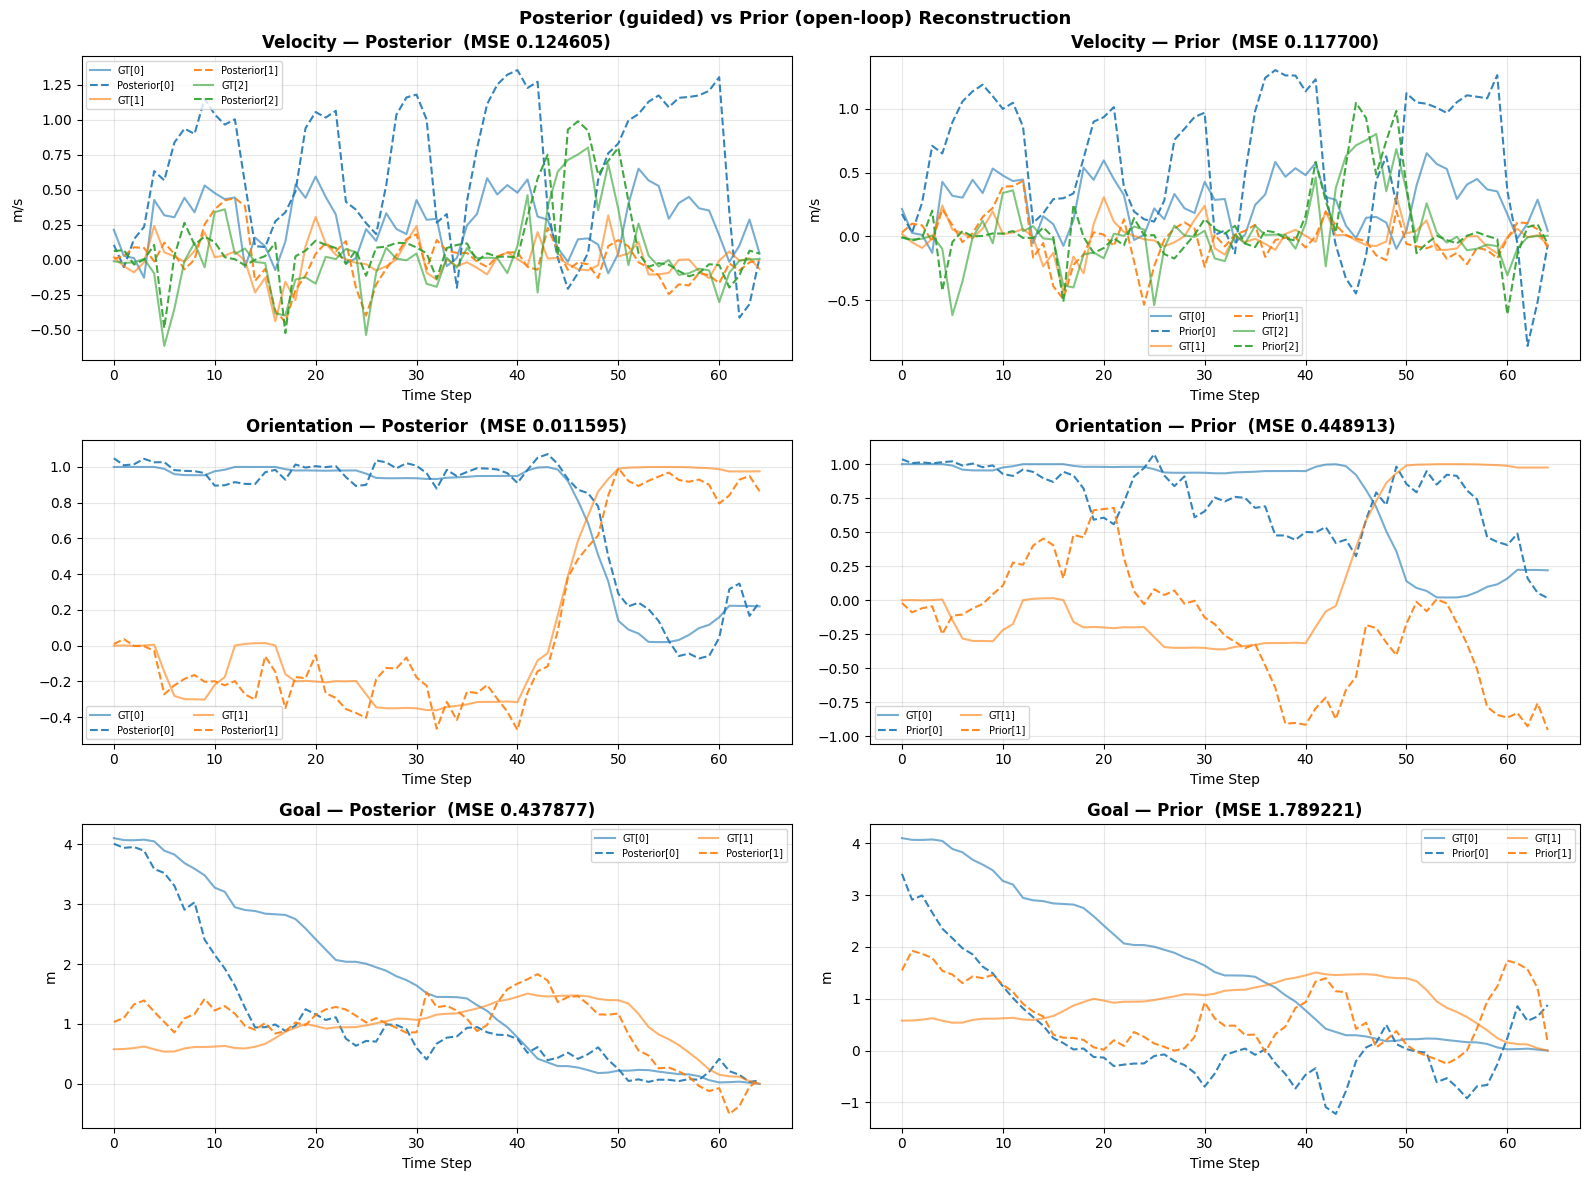

In [12]:

if prior_recons is None:
    print("Prior dream data not available.")
else:
    compare_keys = [k for k in obs_keys if k in prior_recons and k in reconstructions and k in obs_flat]
    if not compare_keys:
        print("No common keys to compare.")
    else:
        time_steps = np.arange(obs_flat[compare_keys[0]].shape[0])
        prior_mse = {k: float(np.mean((prior_recons[k] - obs_flat[k]) ** 2)) for k in compare_keys}
        post_mse  = {k: float(np.mean((reconstructions[k] - obs_flat[k]) ** 2)) for k in compare_keys}

        print("Prior vs Posterior MSE:")
        for k in compare_keys:
            print(f"  {k:12s}  posterior={post_mse[k]:.6f}  prior={prior_mse[k]:.6f}")

        fig, axes = plt.subplots(len(compare_keys), 2, figsize=(16, 4 * len(compare_keys)), squeeze=False)
        fig.suptitle('Posterior (guided) vs Prior (open-loop) Reconstruction', fontsize=13, fontweight='bold')

        ylabel_map = {'velocity': 'm/s', 'position': 'm', 'orientation': '', 'goal': 'm'}

        for row, key in enumerate(compare_keys):
            for col, (label, data) in enumerate([('Posterior', reconstructions[key]),
                                                  ('Prior',     prior_recons[key])]):
                ax = axes[row, col]
                mse = post_mse[key] if col == 0 else prior_mse[key]
                color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
                for dim in range(obs_flat[key].shape[1]):
                    c = color_cycle[dim % len(color_cycle)]
                    ax.plot(time_steps, obs_flat[key][:, dim], '-', color=c,
                            alpha=0.6, linewidth=1.5, label=f'GT[{dim}]')
                    ax.plot(time_steps, data[:, dim], '--', color=c,
                            alpha=0.9, linewidth=1.5, label=f'{label}[{dim}]')
                ax.set_title(f"{key.capitalize()} — {label}  (MSE {mse:.6f})", fontweight='bold')
                ax.set_xlabel('Time Step')
                ax.set_ylabel(ylabel_map.get(key, ''))
                ax.legend(fontsize=7, ncol=2, loc='best')
                ax.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()


Prior dream vs ground truth:
  velocity     MSE: 0.117700
  orientation  MSE: 0.448913
  goal         MSE: 1.789221


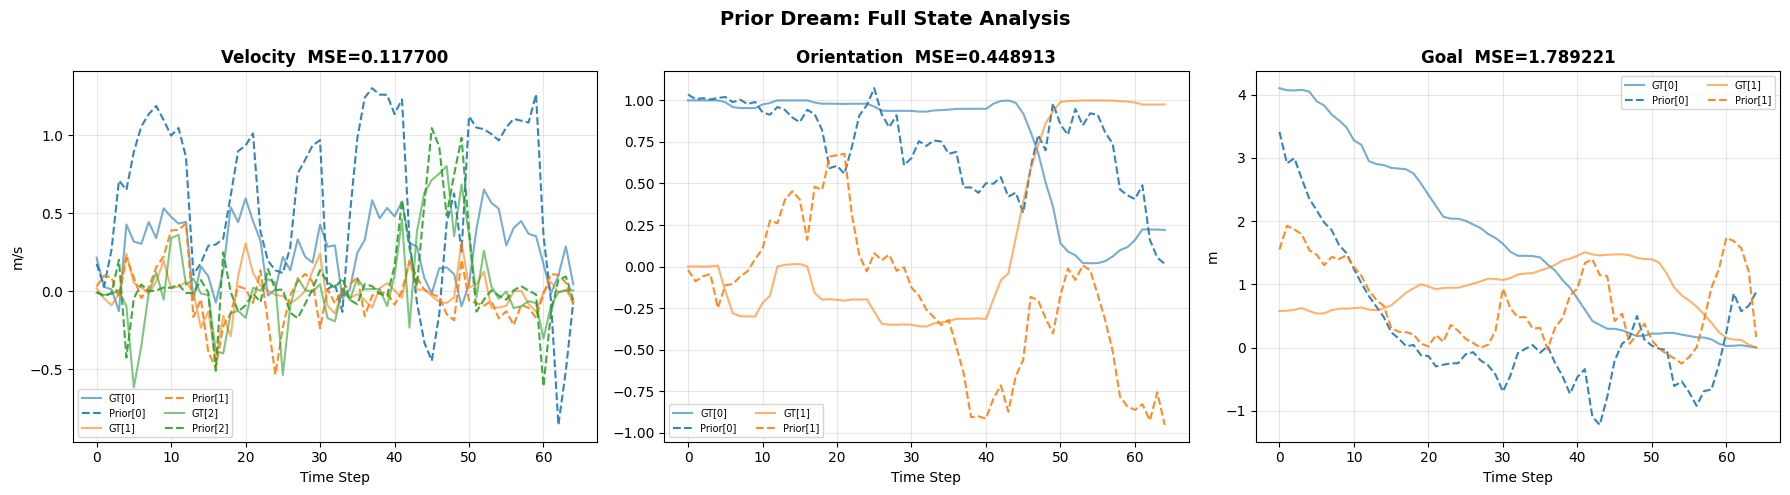

In [13]:

if prior_recons is None:
    print("Prior dream data not available.")
else:
    compare_keys = [k for k in obs_keys if k in prior_recons and k in obs_flat]
    time_steps = np.arange(obs_flat[compare_keys[0]].shape[0])

    print("Prior dream vs ground truth:")
    for key in compare_keys:
        mse = float(np.mean((prior_recons[key] - obs_flat[key]) ** 2))
        print(f"  {key:12s} MSE: {mse:.6f}")

    has_pos  = 'position'    in compare_keys
    has_vel  = 'velocity'    in compare_keys
    has_ori  = 'orientation' in compare_keys
    has_goal = 'goal'        in compare_keys

    state_panels = [k for k in ['velocity', 'orientation', 'goal'] if k in compare_keys]
    n_state = len(state_panels)
    n_rows = 1 + (1 if has_pos else 0)
    n_cols = max(2, n_state)

    fig, axes_grid = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))
    axes_grid = np.array(axes_grid).reshape(n_rows, n_cols)

    color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
    ylabel_map  = {'velocity': 'm/s', 'position': 'm', 'orientation': '', 'goal': 'm'}

    # Row 0: state component plots
    for col, key in enumerate(state_panels):
        ax = axes_grid[0, col]
        mse = float(np.mean((prior_recons[key] - obs_flat[key]) ** 2))
        for dim in range(obs_flat[key].shape[1]):
            c = color_cycle[dim % len(color_cycle)]
            ax.plot(time_steps, obs_flat[key][:, dim],   '-',  color=c, alpha=0.6, linewidth=1.5, label=f'GT[{dim}]')
            ax.plot(time_steps, prior_recons[key][:, dim], '--', color=c, alpha=0.9, linewidth=1.5, label=f'Prior[{dim}]')
        ax.set_title(f"{key.capitalize()}  MSE={mse:.6f}", fontweight='bold')
        ax.set_xlabel('Time Step')
        ax.set_ylabel(ylabel_map.get(key, ''))
        ax.legend(fontsize=7, ncol=2, loc='best')
        ax.grid(True, alpha=0.3)
    for col in range(len(state_panels), n_cols):
        axes_grid[0, col].set_visible(False)

    # Row 1 (if position): top-down trajectory + MSE bar
    if has_pos and n_rows > 1:
        ax_traj = axes_grid[1, 0]
        ax_traj.plot(obs_flat['position'][:, 0],    obs_flat['position'][:, 1],    'b-', linewidth=2, label='Ground truth')
        ax_traj.plot(prior_recons['position'][:, 0], prior_recons['position'][:, 1], 'r--', linewidth=2, label='Prior dream')
        ax_traj.scatter(*obs_flat['position'][0, :2],    color='blue', s=100, marker='o', zorder=5, label='Start GT')
        ax_traj.scatter(*prior_recons['position'][0, :2], color='red',  s=150, marker='x', linewidths=3, zorder=5, label='Start Prior')
        ax_traj.set_xlabel('X (m)'); ax_traj.set_ylabel('Y (m)')
        ax_traj.set_title('Top-Down Position Trajectory', fontweight='bold')
        ax_traj.legend(fontsize=8); ax_traj.grid(True, alpha=0.3); ax_traj.set_aspect('equal', adjustable='datalim')

        ax_bar = axes_grid[1, 1]
        mse_values = [float(np.mean((prior_recons[k] - obs_flat[k]) ** 2)) for k in compare_keys]
        bar_colors = ['red' if v > 0.1 else 'orange' if v > 0.01 else 'green' for v in mse_values]
        ax_bar.bar([k.capitalize() for k in compare_keys], mse_values, color=bar_colors,
                   alpha=0.7, edgecolor='black')
        ax_bar.set_ylabel('MSE (log scale)'); ax_bar.set_title('Prior MSE per Modality', fontweight='bold')
        ax_bar.set_yscale('log'); ax_bar.grid(True, alpha=0.3, axis='y')
        for col in range(2, n_cols):
            axes_grid[1, col].set_visible(False)

    plt.suptitle('Prior Dream: Full State Analysis', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
